# TP - CNN pour reconnaissance de chiffres

Les opérations suivantes sont effectuées dans ce notebook:

- Utilisation de Keras pour plus de simplicité  
- Chargement des images de chiffres manuscrites  
- création du modèle CNN
- entraînement du modèle
- test sur des données 

## Import des librairies

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Cache les warnings CUDA

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [5]:
print("GPU disponible:", len(tf.config.list_physical_devices('GPU')) > 0)
print("Entraînement sur:", "GPU" if tf.config.list_physical_devices('GPU') else "CPU")

GPU disponible: False
Entraînement sur: CPU


## Chargement des données

In [2]:
# Charge MNIST et normalise (0-1)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Ajoute canal (28,28) -> (28,28,1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Encodage one-hot des labels
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Affichage des dimensions des matrices
print("Train:", x_train.shape, "Test:", x_test.shape)

Train: (60000, 28, 28, 1) Test: (10000, 28, 28, 1)


## Visualisation des données

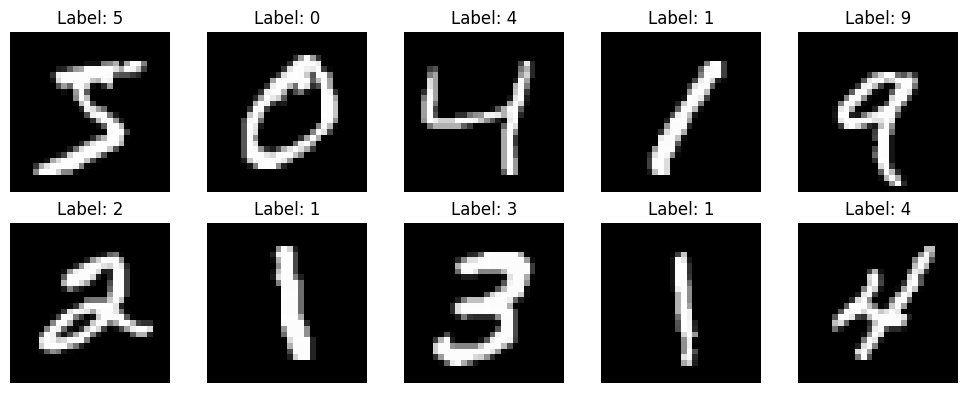

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(f'Label: {np.argmax(y_train[i])}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Création du modèle CNN

In [6]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax"),
])

# Résumé du nombre de paramètres à chaque couche
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

## Entraînement du modèle

In [7]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Entraîne (5 époques = ~99%)
history = model.fit(x_train, y_train, batch_size=128, epochs=5, validation_split=0.1, verbose=1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8934 - loss: 0.3631 - val_accuracy: 0.9790 - val_loss: 0.0800
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9670 - loss: 0.1103 - val_accuracy: 0.9835 - val_loss: 0.0584
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9735 - loss: 0.0849 - val_accuracy: 0.9872 - val_loss: 0.0457
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9779 - loss: 0.0703 - val_accuracy: 0.9883 - val_loss: 0.0417
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9816 - loss: 0.0620 - val_accuracy: 0.9893 - val_loss: 0.0407


In [11]:
# Évaluation du modèle sur le test
score = model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {score[0]:.4f}, Accuracy: {score[1]*100:.2f}%")

Test loss: 0.0385, Accuracy: 98.75%


## Test sur 10 images non vues par le modèle

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


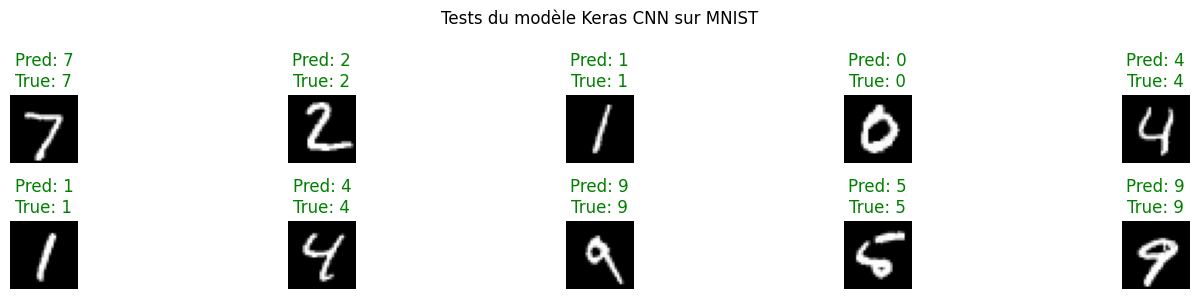

Précision sur 10: 100.0%


In [9]:
predictions = model.predict(x_test[:10])
pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test[:10], axis=1)

plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    color = 'green' if pred_labels[i] == true_labels[i] else 'red'
    plt.title(f'Pred: {pred_labels[i]}\nTrue: {true_labels[i]}', color=color, fontsize=12)
    plt.axis('off')
plt.suptitle('Tests du modèle Keras CNN sur MNIST')
plt.tight_layout()
plt.show()

print(f"Précision sur 10: {100*np.sum(pred_labels == true_labels)/10:.1f}%")

## Prédiction sur une image unique du test set

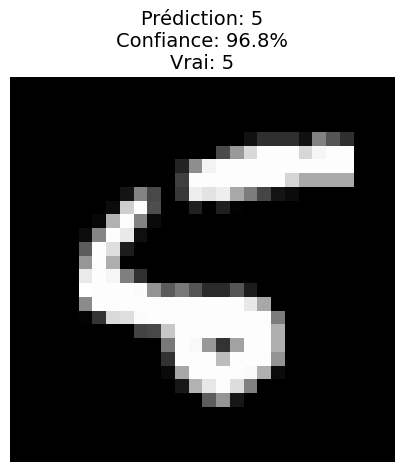

In [14]:
idx = 8  # Changez l'index si vous voulez
img = x_test[idx:idx+1]
pred = model.predict(img, verbose=0)
pred_label = np.argmax(pred)
confidence = np.max(pred) * 100

plt.figure(figsize=(5,5))
plt.imshow(x_test[idx].squeeze(), cmap='gray')
plt.title(f'Prédiction: {pred_label}\nConfiance: {confidence:.1f}%\nVrai: {np.argmax(y_test[idx])}', fontsize=14)
plt.axis('off')
plt.show()